In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ex 3.1

The dataset contains quarterly numbers of overnight trips in different regions of Australia, between 1998 and 2018. The trips are categorised according to the purpose of the trip. Find out the region with the greatest mean across these years, where the purpose of the trips was business. Plot the time series representing business trips to this region, showing the mean and standard deviation on the plot.

Complete the solution by writing your code instead of "???".

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/australia_tourism.csv",
                 parse_dates=["date_time"], index_col="date_time")
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24320 entries, 1998-01-01 to 2017-10-01
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   24320 non-null  object 
 1   State    24320 non-null  object 
 2   Purpose  24320 non-null  object 
 3   Trips    24320 non-null  float64
dtypes: float64(1), object(3)
memory usage: 950.0+ KB


In [6]:
df.head()

,Region,State,Purpose,Trips
date_time,,,,
1998-01-01,Adelaide,South Australia,Business,135.077690
1998-04-01,Adelaide,South Australia,Business,109.987316
1998-07-01,Adelaide,South Australia,Business,166.034687
1998-10-01,Adelaide,South Australia,Business,127.160464
1999-01-01,Adelaide,South Australia,Business,137.448533


In [5]:
largest_mean = 0
largest_mean_region = None

for region in df["Region"].unique():
    tdf = df[(df["Region"] == region) & (df["Purpose"] == "Business")]
    mean = tdf["Trips"].mean()

    if mean > largest_mean:
        largest_mean = mean
        largest_mean_region = region
print(f"Region with largest mean: {largest_mean_region} ({largest_mean:.2f})")

Region with largest mean: Sydney (602.04)


<Axes: xlabel='date_time'>

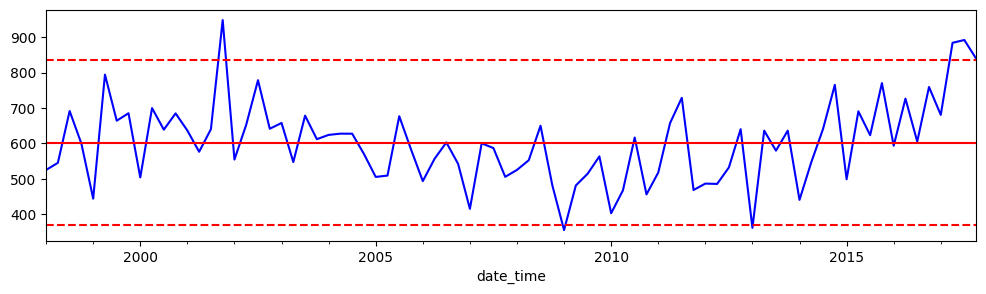

In [7]:
# select the business trips for the region with the largest mean
tdf = df[(df["Region"] == largest_mean_region) & (df["Purpose"] == "Business")].copy()

# add columns for the mean and the upper and lower bounds of the 95% confidence interval
tdf.loc[:,"Mean"] = largest_mean
tdf.loc[:, "2*Stdev"] = tdf["Mean"] + 2 * tdf["Trips"].std()
tdf.loc[:, "-2*Stdev"] = tdf["Mean"] - 2 * tdf["Trips"].std()

# plot the lines with appropriate styles
tdf.plot(y=["Trips", "Mean", "2*Stdev", "-2*Stdev"],
         figsize=(12, 3),
         style={"Trips": "blue", "Mean": "r", "2*Stdev": "--r", "-2*Stdev": "--r"},
         legend=False,
         use_index=True)

# Ex 3.2

Plot the ACF and PACF of the time series from Ex.3.1. Does the series look more like white noise or red noise? What other insights can you get from these plots?

Complete the solution by writing your code instead of "???".

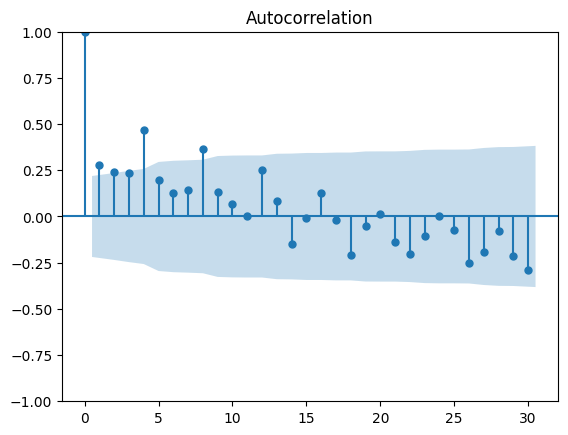

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

tdf = df[(df["Region"] == largest_mean_region) & (df["Purpose"] == "Business")].copy()

_ = plot_acf(tdf['Trips'], lags=30)

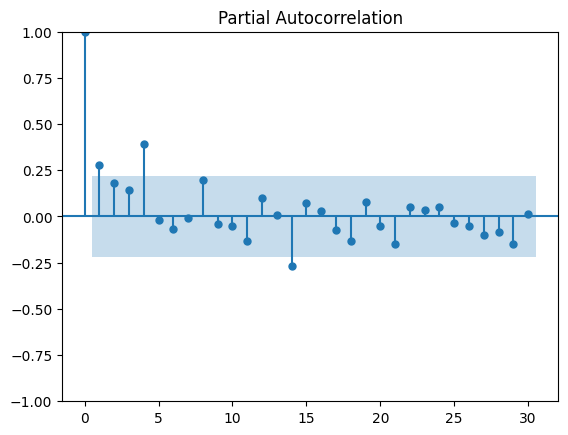

In [14]:
_ = plot_pacf(tdf['Trips'], lags=30)

# Ex 3.3

The US macroeconomic dataset (available in the sktime package) contains indicators such as GDP, inflation, and interest rate from 1959 to 2009. Find out which of them are stationary and which are not, using the ADF test and the significance level of 0.05. Find out the series with the strongest evidence of stationarity, plot it as well as its ACF plot. Similarly, find out the series with the strongest evidence of non-stationarity, plot the series and its ACF plot.

Description of the variables can be found [here](https://www.statsmodels.org/dev/datasets/generated/macrodata.html).

You may need to first install the `sktime` package, by running this command in a separate call:

`!pip install sktime`

Complete the solution by writing your code instead of "???".

In [16]:
!pip install sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 18.0 MB/s eta 0:00:00


In [17]:
from sktime.datasets.forecasting import Macroeconomic

df = Macroeconomic().load()[1]

df.info()

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 203 entries, 1959Q1 to 2009Q3
Freq: Q-DEC
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   realgdp   203 non-null    float64
 1   realcons  203 non-null    float64
 2   realinv   203 non-null    float64
 3   realgovt  203 non-null    float64
 4   realdpi   203 non-null    float64
 5   cpi       203 non-null    float64
 6   m1        203 non-null    float64
 7   tbilrate  203 non-null    float64
 8   unemp     203 non-null    float64
 9   pop       203 non-null    float64
 10  infl      203 non-null    float64
 11  realint   203 non-null    float64
dtypes: float64(12)
memory usage: 20.6 KB


In [19]:
df.head()

,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
Period,,,,,,,,,,,,
1959Q1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959Q2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
1959Q3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
1959Q4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
1960Q1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [20]:
from statsmodels.tsa.stattools import adfuller

stationary_example = None
nonstationary_example = None

pvals = {}

for col in df.columns:
    adf_stat, pval, lags, obs, crit_vals, icbest = adfuller(df[col], regression="n")
    pvals[col] = pval

# print the column with the smallest p-value
stationary_example = min(pvals, key=pvals.get)
print(f"Column with smallest p-value: {stationary_example} (p-value: {pvals[stationary_example]:.3f})")

# print the column with the greatest p-value
nonstationary_example = max(pvals, key=pvals.get)
print(f"Column with greatest p-value: {nonstationary_example} (p-value: {pvals[nonstationary_example]:.3f})")

Column with smallest p-value: realint (p-value: 0.014)
Column with greatest p-value: realdpi (p-value: 1.000)


<Axes: xlabel='Period'>

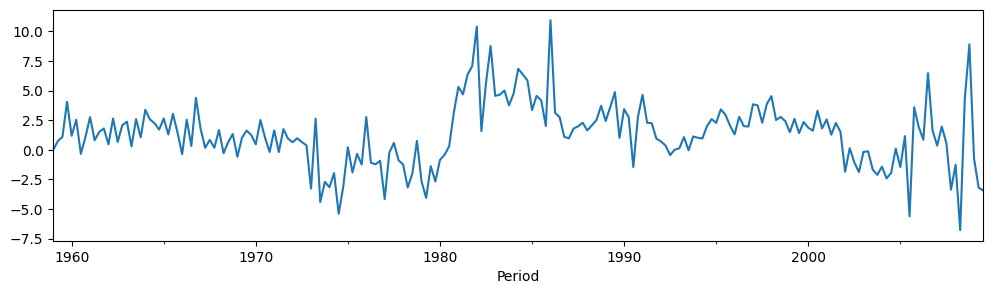

In [23]:
# Stationary series
df['realint'].plot(figsize=(12, 3))

<Axes: xlabel='Period'>

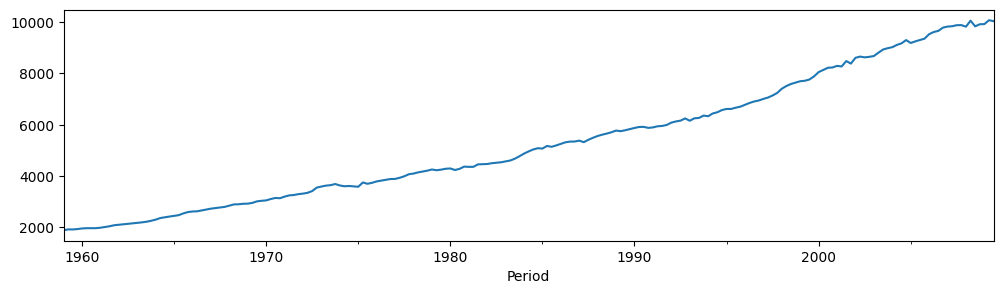

In [24]:
# Non-stationary series
df['realdpi'].plot(figsize=(12, 3))

# Ex 3.4

The dataset contains quarterly numbers of overnight trips in different regions of Australia, between 1998 and 2018. The code below converts the data into a pivot table, where the rows contain dates, the rows contain regions, and cells contain the number of trips to those regions in the given quarters. Your task is to find strong leading indicators of business trips to Adelaide Hills. Perform the following steps:

1. Find out which columns represent stationary time series  (use the significance level of 0.1).
2. Measure the cross-correlation between "Adelaide Hills" each stationary series.
3. Describe significant correlations.

Most of the solution is written, you need to supply your code instead of the question marks ("???").

In [ ]:
# Load the data
df = pd.read_csv("https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/australia_tourism.csv",
                 parse_dates=["date_time"])
df.info()

In [ ]:
# Select data on business trips
df = df[df["Purpose"] == ???]

# Pivot so each region is a column, each date is a row
pivot = df.pivot_table(index="???", aggfunc="sum",
                       columns='???', values='Trips',
                       observed=False)
pivot.head(3)

In [ ]:
# find non-stationary columns using the sign level of 0.1 and drop them

from statsmodels.tsa.stattools import adfuller

drop_cols = []

for c in pivot.columns:
    adf_stat, pval, lags, obs, crit_vals, icbest = adfuller(???, regression="n")
    if pval > ???:
        drop_cols.append(c)

pivot = pivot.drop(drop_cols, axis=1)
pivot.info()

In [ ]:
import statsmodels.api as sm

# the target is Adelaide Hills
xcorrs = sm.tsa.stattools.ccf(???, ???, adjusted=False)
xcorrs[:5]

In [ ]:
def build_ccf(y, x, max_lags=10):
    ccf_lags = sm.tsa.stattools.ccf(y, x, adjusted=False)
    plt.figure(figsize=[8, 3])
    lags = np.arange(max_lags)
    ax = sns.lineplot(y=ccf_lags[:max_lags], x=lags)
    sign_band = 1.96 / np.sqrt(y.shape[0])
    plt.axhspan(-sign_band, sign_band, alpha=0.2)
    ax.set(xlabel='Lags', ylabel='cross-correlation')

# the target is Adelaide Hills
build_ccf(???, ????)